# 04 — Region Analysis
In-depth analysis of sales distribution, trends, and risks by region. This notebook generates regional insights used in the Streamlit dashboard.
Output: `le_region.pkl`, `le_category.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Library is Ready')

✅ Library is Ready


## 1. Load Data

In [2]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin'] = (df['profit'] / df['sales']) * 100
df['revenue_per_unit'] = df['sales'] / df['quantity']
print(f'Load Data: {df.shape}')
print(f"Region: {df['region'].unique().tolist()}")
print(f"Unique city: {df['city'].nunique()}")

Load Data: (5000, 19)
Region: ['South', 'North', 'East', 'West']
Unique city: 20


## 2. Performa per Wilayah

In [3]:
region_summary = df.groupby('region').agg(
    total_orders=('order_id', 'count'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin', 'mean'),
    trending_pct=('is_trending', 'mean')
).reset_index()
region_summary['trending_pct'] *= 100

print('=== SUMMARY BY REGION ===')
print(region_summary.round(2).to_string(index=False))

=== SUMMARY BY REGION ===
region  total_orders  total_sales  total_profit  avg_margin  trending_pct
  East          1256 135811637.95   20532558.12       14.91         41.88
 North          1288 143578246.10   21343004.33       14.84         43.09
 South          1215 123230166.95   18253049.32       14.98         36.71
  West          1241 131045973.35   19580123.14       14.97         38.36


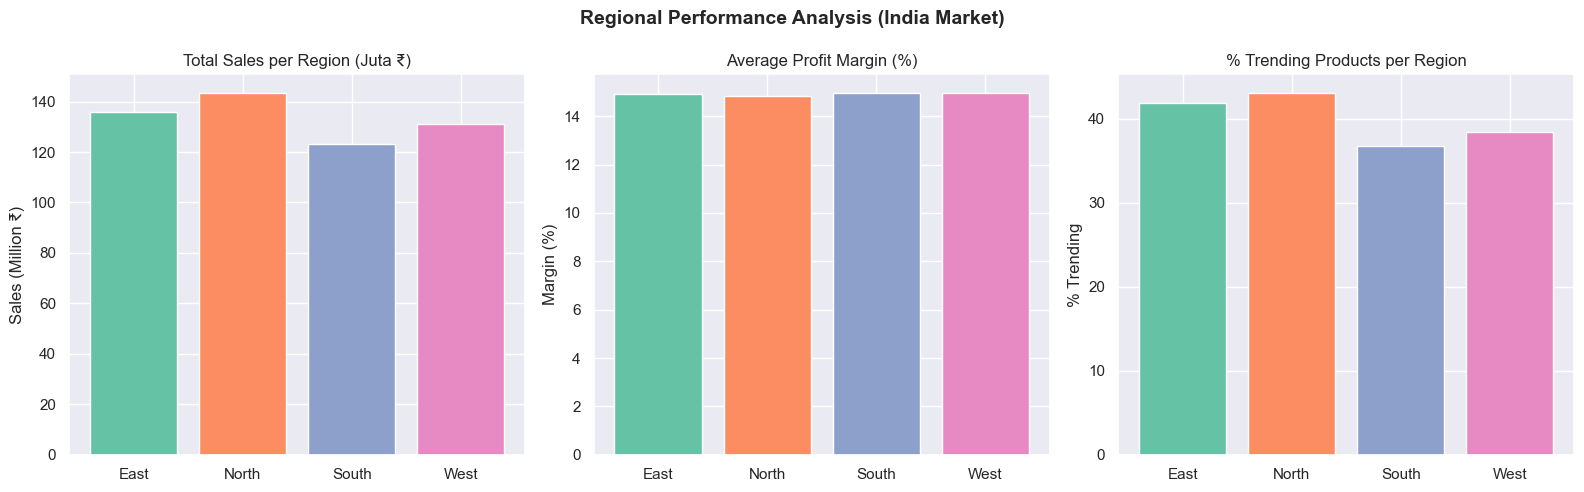

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use a consistent color palette
colors = sns.color_palette('Set2', 4)

# Plot 1: Total Sales per Region (In Million Rupees)
axes[0].bar(region_summary['region'], region_summary['total_sales']/1e6, color=colors)
axes[0].set_title('Total Sales per Region (Juta ₹)')
axes[0].set_ylabel('Sales (Million ₹)')

# Plot 2: Average Profit Margin (%)
axes[1].bar(region_summary['region'], region_summary['avg_margin'], color=colors)
axes[1].set_title('Average Profit Margin (%)')
axes[1].set_ylabel('Margin (%)')

# Plot 3: % Trending Products per Region
axes[2].bar(region_summary['region'], region_summary['trending_pct'], color=colors)
axes[2].set_title('% Trending Products per Region')
axes[2].set_ylabel('% Trending')

plt.suptitle('Regional Performance Analysis (India Market)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Heatmap: Region × Kategori

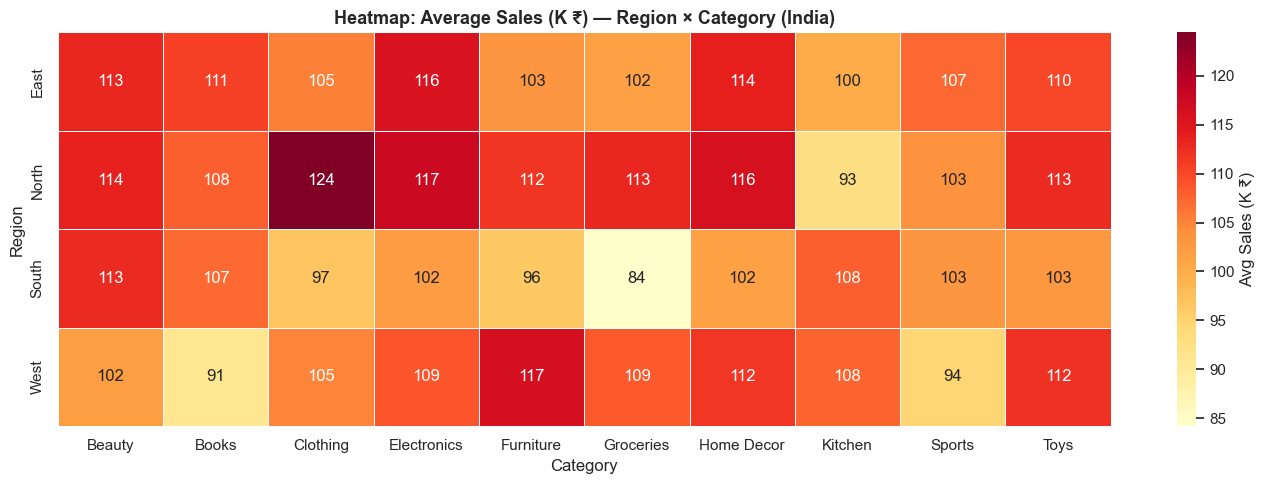

In [5]:
# Pivot: Average sales per region x category
pivot_sales = df.pivot_table(values='sales', index='region', columns='category', aggfunc='mean')

plt.figure(figsize=(14, 5))
# We divide by 1000 to display in "Kilo Rupees" (K ₹) to prevent the numbers from being too long
sns.heatmap(pivot_sales/1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Sales (K ₹)'})

plt.title('Heatmap: Average Sales (K ₹) — Region × Category (India)', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

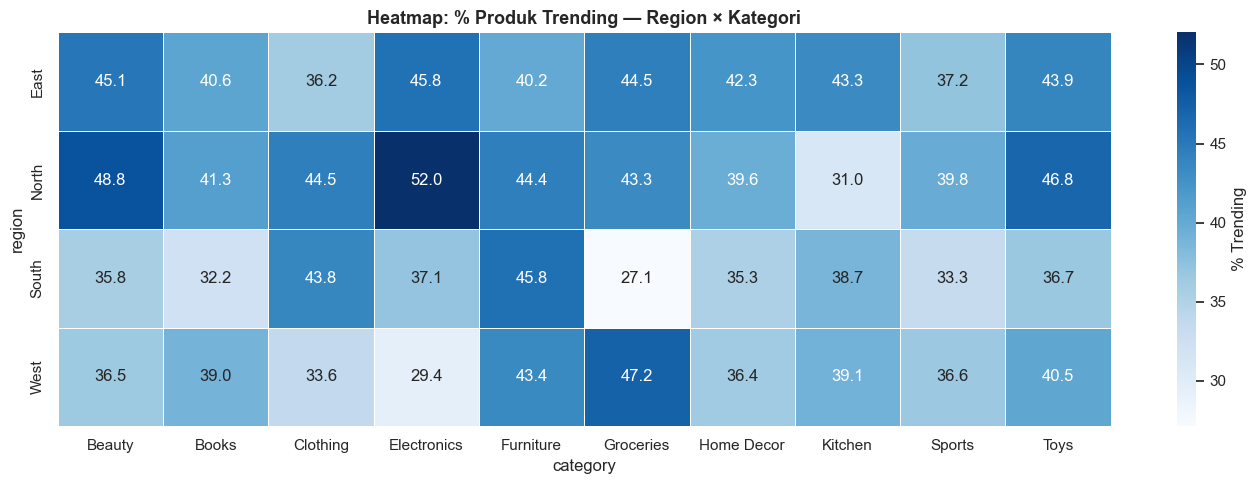

In [6]:
# Pivot: % trending per region x category
pivot_trend = df.pivot_table(values='is_trending', index='region', columns='category', aggfunc='mean') * 100

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_trend, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '% Trending'})
plt.title('Heatmap: % Produk Trending — Region × Kategori', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Top 10 Cities by Sales

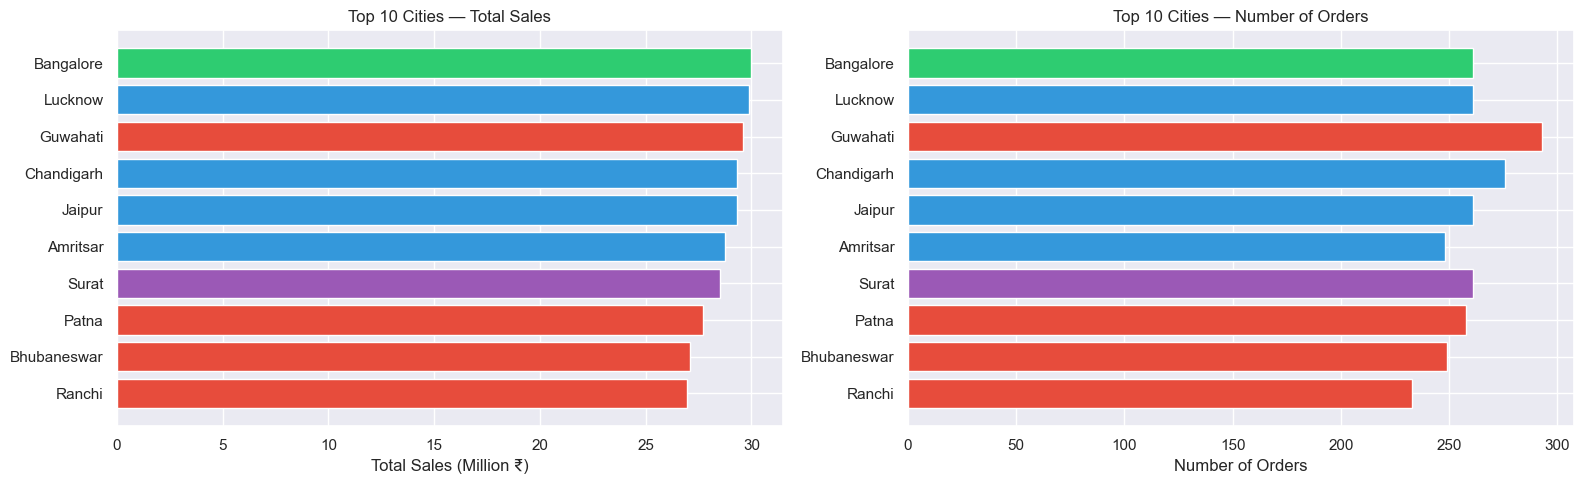

       city region  total_sales  total_profit  orders
  Bangalore  South  29989840.85    4416914.72     261
    Lucknow  North  29901483.40    4523681.09     261
   Guwahati   East  29606888.90    4487271.28     293
 Chandigarh  North  29331057.35    4375379.60     276
     Jaipur  North  29319402.90    4353577.84     261
   Amritsar  North  28746184.20    4202631.34     248
      Surat   West  28532934.65    4294995.22     261
      Patna   East  27702815.20    4131315.44     258
Bhubaneswar   East  27088786.45    4070957.02     249
     Ranchi   East  26948513.25    4113313.69     233


In [7]:
top_cities = df.groupby(['city','region']).agg(
    total_sales=('sales','sum'),
    total_profit=('profit','sum'),
    orders=('order_id','count')
).reset_index().sort_values('total_sales', ascending=False).head(10)

palette = {'South':'#2ecc71','North':'#3498db','East':'#e74c3c','West':'#9b59b6'}
colors_bar = [palette[r] for r in top_cities['region']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top_cities['city'][::-1], top_cities['total_sales'][::-1]/1e6, color=colors_bar[::-1])
axes[0].set_xlabel('Total Sales (Million ₹)')
axes[0].set_title('Top 10 Cities — Total Sales')

axes[1].barh(top_cities['city'][::-1], top_cities['orders'][::-1], color=colors_bar[::-1])
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Top 10 Cities — Number of Orders')

plt.tight_layout()
plt.show()
print(top_cities.to_string(index=False))

## 5. Monthly Trends per Region

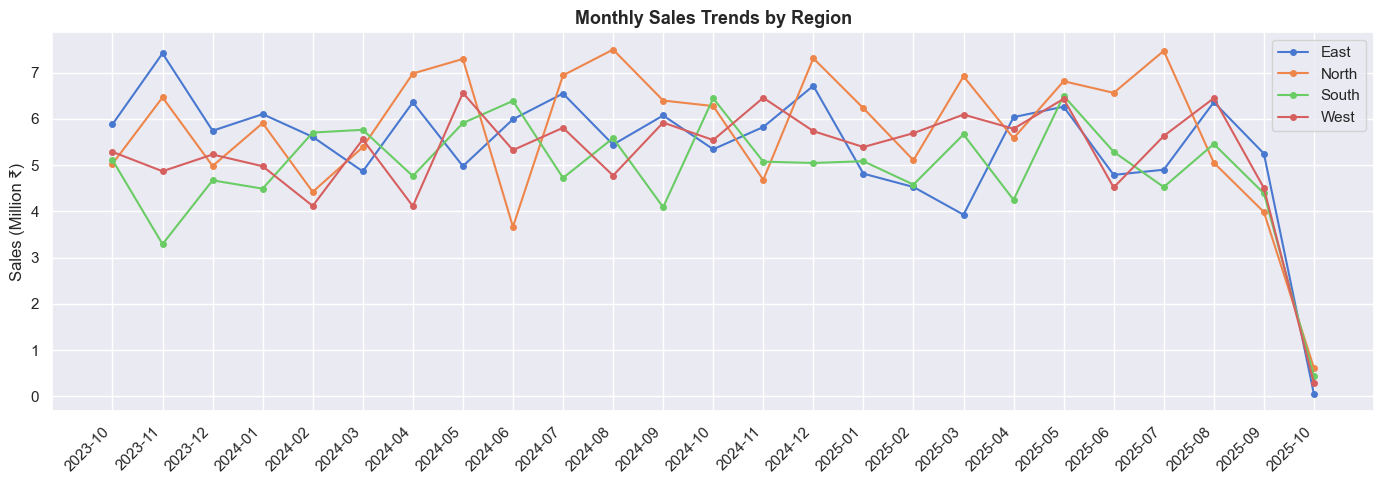

In [8]:
monthly = df.groupby(['year','month','region'])['sales'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('period')

plt.figure(figsize=(14, 5))
for region, grp in monthly.groupby('region'):
    plt.plot(grp['period'], grp['sales']/1e6, marker='o', markersize=4, label=region)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Sales (Million ₹)')
plt.title('Monthly Sales Trends by Region', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save Encoder Region & Category

In [9]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_region.fit(df['region'])

le_category = LabelEncoder()
le_category.fit(df['category'])

with open('../Notebooks/le_region.pkl', 'wb') as f:
    pickle.dump(le_region, f)

with open('../Notebooks/le_category.pkl', 'wb') as f:
    pickle.dump(le_category, f)

print('✅ Saved:')
print('   📦 le_region.pkl   →', le_region.classes_.tolist())
print('   📦 le_category.pkl →', le_category.classes_.tolist())
print()
print('✅ Region Analysis Done!')

✅ Saved:
   📦 le_region.pkl   → ['East', 'North', 'South', 'West']
   📦 le_category.pkl → ['Beauty', 'Books', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Home Decor', 'Kitchen', 'Sports', 'Toys']

✅ Region Analysis Done!
